In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv(r"C:\Users\thana\Desktop\flight_analysis\data\flight_ml_ready.csv")

print("Γραμμές:", len(df))
print("Έτοιμο!")

Γραμμές: 1928371
Έτοιμο!


In [2]:
features = [
    "Month_sin", "Month_cos",
    "DayOfWeek", "IS_WEEKEND",
    "CRSDepTime", "Distance",
    "CarrierDelay", "NASDelay"
]

le = LabelEncoder()
df["Carrier_encoded"] = le.fit_transform(df["UniqueCarrier"])
features.append("Carrier_encoded")

X = df[features]
y = df["DELAYED"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 1542696
Test size: 385675


In [3]:
# Εκπαίδευση όλων των μοντέλων

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

# NN
mlp = MLPClassifier(hidden_layer_sizes=(128, 64, 32),
                    activation="relu", solver="adam",
                    max_iter=50, random_state=42)
mlp.fit(X_train_scaled, y_train)

print("Τα μοντέλα εκπαιδεύτηκαν!")


Τα μοντέλα εκπαιδεύτηκαν!


c:\Users\thana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


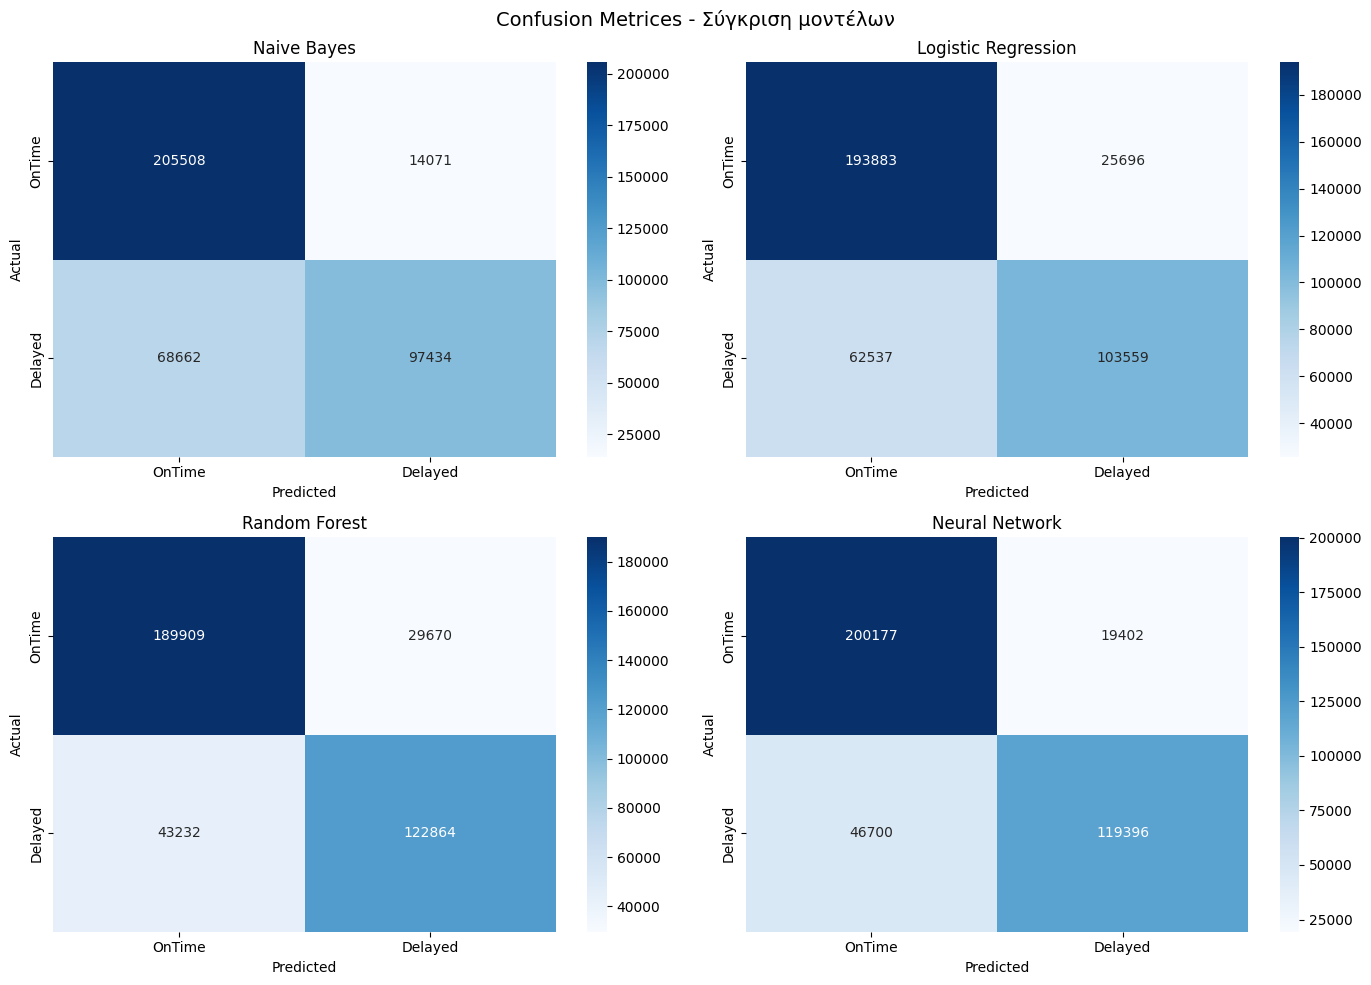

In [7]:
# Confusion Metrices
models = {
    "Naive Bayes": nb,
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Neural Network": mlp
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                ax=axes[idx],
                xticklabels=["OnTime", "Delayed"],
                yticklabels=["OnTime", "Delayed"])
    axes[idx].set_title(f"{name}")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")
    
plt.suptitle("Confusion Metrices - Σύγκριση μοντέλων", fontsize=14)
plt.tight_layout()
plt.show()

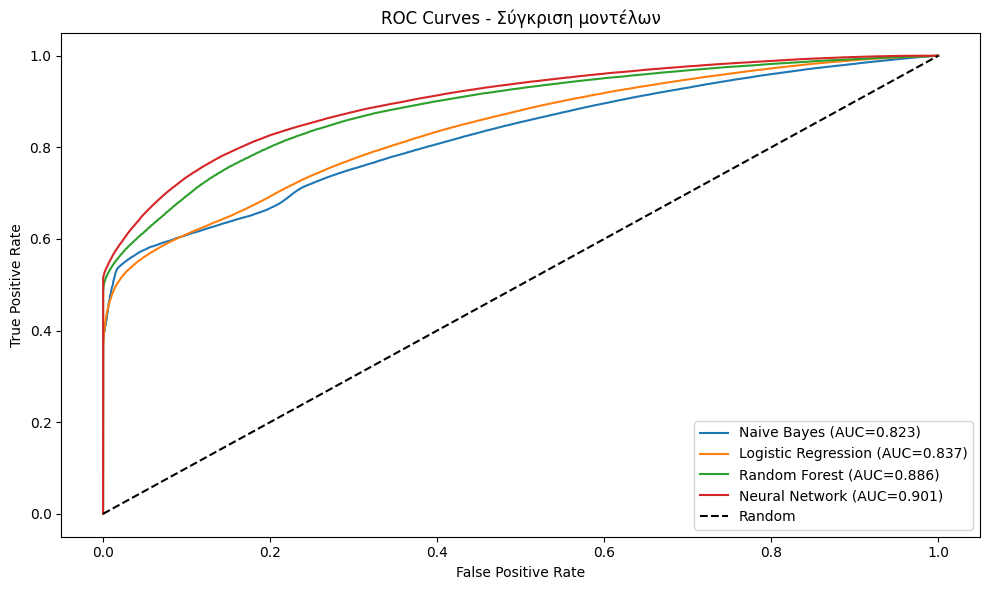

In [8]:
# ROC curves
plt.figure(figsize=(10, 6))

for name,model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.title("ROC Curves - Σύγκριση μοντέλων")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\thana\AppData\Local\Temp\ipykernel_7000\455433219.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="Greens")


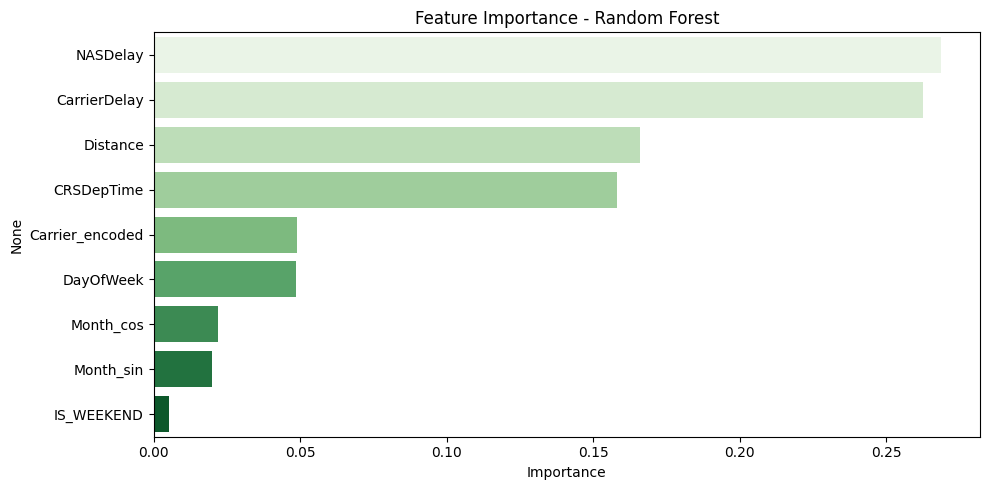

In [10]:
# Feature Importance (Random Forest)
importances = pd.Series(rf.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette="Greens")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [11]:
# Τελική σύγκριση
results = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        "Μοντέλο": name,
        "Accuracy": f"{report['accuracy']:.3f}",
        "F1 (macro)": f"{report['macro avg']['f1-score']:.3f}",
        "ROC-AUC": f"{roc_auc_score(y_test, y_proba):.3f}"
    })
    
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

            Μοντέλο Accuracy F1 (macro) ROC-AUC
        Naive Bayes    0.785      0.767   0.823
Logistic Regression    0.771      0.758   0.837
      Random Forest    0.811      0.805   0.886
     Neural Network    0.829      0.821   0.901


## Τελική Σύγκριση Μοντέλων

### Νικητής: Neural Network
- Καλύτερο σε Accuracy (82.9%), F1 (0.821) και ROC-AUC (0.901)
- ROC-AUC > 0.90 θεωρείται εξαιρετικό για binary classification

### Παρατηρήσεις:
- **Naive Bayes**: Απλό και γρήγορο αλλά υστερεί σε F1 — 
  δυσκολεύεται με τις non-linear σχέσεις των features
- **Logistic Regression**: Καλό baseline, ερμηνεύσιμο, 
  αλλά χαμηλότερη απόδοση λόγω γραμμικής φύσης
- **Random Forest**: Ισχυρό μοντέλο, δεύτερο καλύτερο — 
  πλεονέκτημα η feature importance για ερμηνευσιμότητα
- **Neural Network**: Καλύτερη απόδοση συνολικά — 
  αντιλαμβάνεται πολύπλοκες non-linear σχέσεις

### Συμπέρασμα:
Για πρόβλεψη καθυστερήσεων πτήσεων σε production περιβάλλον,
το Neural Network είναι η βέλτιστη επιλογή. Αν απαιτείται
ερμηνευσιμότητα, το Random Forest αποτελεί εξαιρετική εναλλακτική.